# Energy Model Comparison — Variant Selection

**Instruments:** `cl1s` (XGB individual, SIGNAL), `ho1s` / `rb1s` / `ng1s` (energy\_all pool — NO SIGNAL, exploratory)

**Discipline:**
- Phase 1 selection on **TRAIN** only via CPCV (n=6, k=2, embargo=0.01 → 15 paths)
- **Locked pick committed to CSV before Phase 2 begins**
- Phase 2: single-shot OOS on sealed test; run once
- Non-locked variants in Phase 2 are **diagnostic only — never used for re-selection**
- PCA fitted per fold on TRAIN rows only; test rows transformed, never fitted

**Pooled-model mechanics (ho1s / rb1s / ng1s):**
Each variant is a *separate* energy\_all refit on that instrument's feature subset. Training always uses the full 761-event pooled set; scoring uses only the target instrument's own slice (CPCV test rows in Phase 1, sealed-test rows in Phase 2).


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings; warnings.filterwarnings('ignore')
from IPython.display import Image, display

BASE = Path('outputs/model_comparison/energy')

def show(path, width=950):
    p = Path(path)
    if p.exists(): display(Image(str(p), width=width))

def load(path):
    p = Path(path)
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

cpcv_df   = load(BASE / 'cpcv_results.csv')
locked_df = load(BASE / 'locked_picks.csv')
oos_df    = load(BASE / 'oos_results.csv')
locked_picks = locked_df.set_index('inst')['locked_variant'].to_dict() if not locked_df.empty else {}
print('Locked picks:', locked_picks)


Locked picks: {'cl1s': 'reduced', 'ho1s': 'reduced', 'rb1s': 'reduced', 'ng1s': 'reduced'}


## Variant Definitions

| Instrument | Family / Pool | Full | Pruned | Reduced |
|---|---|---|---|---|
| `cl1s` | XGB / individual | All ~101 features | C14\_f11 (5 features) | `f11_move_z` + `f2_vol_60` (2 raw) |
| `ho1s` | Logistic / energy\_all | All ~104 features | F5\_signal + C13\_f11 + C6\_f2 (15 features) | 7 raw + PC1+PC2 of C6\_f2 = **9 inputs** |
| `rb1s` | Logistic / energy\_all | All ~104 features | F5\_signal + C13\_f11 (11 features) | 7 raw features |
| `ng1s` | RF / energy\_all | All ~104 features | C13\_f11 + C9\_f11\_lowfreq\_macro (12 features) | 4 raw + PC1+PC2 of C9\_f11\_lowfreq\_macro = **6 inputs** |

> **cl1s reduced rationale:** `f11_move_z` and `f2_vol_60` are the two dominant SHAP features and load on *opposite* PC1 signs (PC1 explains 67% of C14\_f11 variance). Using both raw representatives rather than PC1 is appropriate for a tree model — it can non-linearly combine them without collapsing the contrast.

> **ng1s pruned / reduced — F5\_signal deliberately excluded:** `f5_signal` MDA is negative for ng1s and the signal near-never goes long, making it a near-constant detrimental feature. Removing it recovers substantial predictive capacity.

> **PCA discipline:** `StandardScaler → PCA` fitted on TRAIN rows only per fold (Phase 1) and on the full train set (Phase 2). Test rows are transformed only.


---
## Phase 1 — CPCV Variant Scoring (TRAIN only)

CPCV n=6, k=2, embargo=0.01 → 15 paths. ng1s: 3 paths skipped (thin pooled slice).

**1SE lock rule:** threshold = full\_mean − full\_SE. Simplest variant (reduced < pruned < full) with mean AUC ≥ threshold is locked.


In [2]:
if not cpcv_df.empty:
    SIMP = {'reduced': 0, 'pruned': 1, 'full': 2}
    def _hl(row):
        locked = locked_picks.get(row['inst'], '')
        return ['background-color: #C8E6C9' if row['variant'] == locked else '' for _ in row]
    ordered = (
        cpcv_df.copy()
        .assign(s=lambda d: d['variant'].map(SIMP))
        .sort_values(['inst','s']).drop(columns='s')
    )
    fmt = {'auc_mean':'{:.4f}','auc_std':'{:.4f}','auc_se':'{:.4f}','logloss':'{:.4f}','brier':'{:.4f}'}
    display(
        ordered[['inst','variant','auc_mean','auc_std','auc_se','logloss','brier','n_paths']]
        .style.format(fmt).apply(_hl, axis=1)
        .set_caption('Phase 1 CPCV — all variants (green = locked per 1SE rule)')
    )


,inst,variant,auc_mean,auc_std,auc_se,logloss,brier,n_paths
2,cl1s,reduced,0.8292,0.0643,0.0166,0.6044,0.2076,15
1,cl1s,pruned,0.7505,0.1027,0.0265,0.6557,0.2313,15
0,cl1s,full,0.6975,0.1390,0.0359,0.6568,0.2326,15
5,ho1s,reduced,0.8475,0.2627,0.0678,0.5589,0.1877,15
4,ho1s,pruned,0.7086,0.2915,0.0753,0.5949,0.1915,15
3,ho1s,full,0.6984,0.3034,0.0783,0.6103,0.1686,15
11,ng1s,reduced,0.6718,0.1716,0.0495,0.6060,0.2074,12
10,ng1s,pruned,0.6639,0.2290,0.0661,0.6314,0.2194,12
9,ng1s,full,0.4087,0.2591,0.0748,0.6642,0.2352,12
8,rb1s,reduced,0.6826,0.1059,0.0273,0.6586,0.2321,15


### CL1S — XGB / individual | SIGNAL

cl1s is the only confirmed-signal energy instrument. The 2-feature reduced variant outperforms full in-sample — both dominant SHAP representatives capture the essential momentum/vol structure.


,variant,auc_mean,auc_std,auc_se,logloss,brier,n_paths
0,full,0.6975,0.1390,0.0359,0.6568,0.2326,15
1,pruned,0.7505,0.1027,0.0265,0.6557,0.2313,15
2,reduced,0.8292,0.0643,0.0166,0.6044,0.2076,15


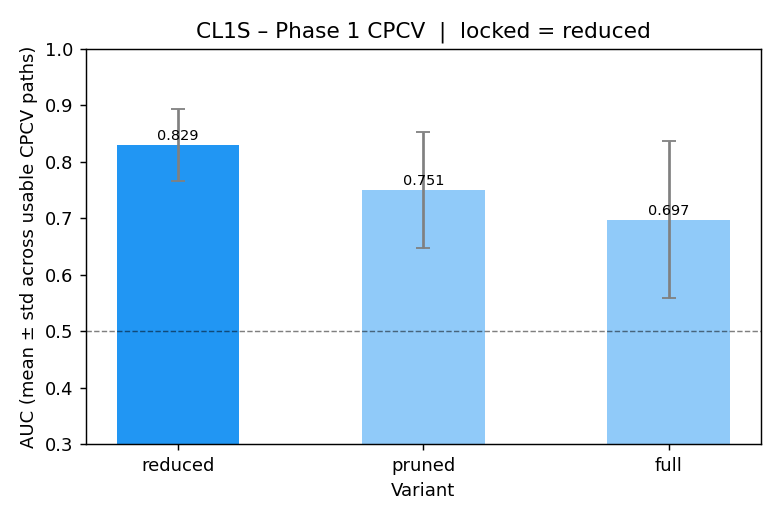

In [3]:
_inst = 'cl1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_fmt2 = {'auc_mean':'{:.4f}','auc_std':'{:.4f}','auc_se':'{:.4f}','logloss':'{:.4f}','brier':'{:.4f}'}
if not _rows.empty:
    display(
        _rows[['variant','auc_mean','auc_std','auc_se','logloss','brier','n_paths']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV (green = locked: ' + _locked + ')')
    )
show(BASE / ('cl1s_cpcv_chart.png'), width=700)


### HO1S — Logistic / energy_all pool | NO SIGNAL — exploratory

ho1s has only 34 events in the train pool and 27 in test. The ±0.30 fold variance is expected; any high OOS number here is likely lucky sampling on a very thin slice and MUST NOT influence the locked pick.


,variant,auc_mean,auc_std,auc_se,logloss,brier,n_paths
3,full,0.6984,0.3034,0.0783,0.6103,0.1686,15
4,pruned,0.7086,0.2915,0.0753,0.5949,0.1915,15
5,reduced,0.8475,0.2627,0.0678,0.5589,0.1877,15


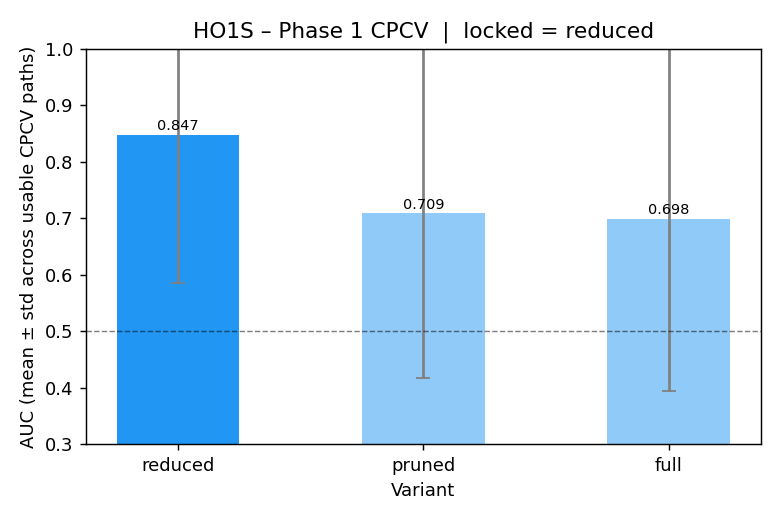

In [4]:
_inst = 'ho1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_fmt2 = {'auc_mean':'{:.4f}','auc_std':'{:.4f}','auc_se':'{:.4f}','logloss':'{:.4f}','brier':'{:.4f}'}
if not _rows.empty:
    display(
        _rows[['variant','auc_mean','auc_std','auc_se','logloss','brier','n_paths']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV (green = locked: ' + _locked + ')')
    )
show(BASE / ('ho1s_cpcv_chart.png'), width=700)


### RB1S — Logistic / energy_all pool | NO SIGNAL — exploratory

rb1s has 420 events — the dominant contributor to the energy_all pool. Results are more stable than ho1s/ng1s.


,variant,auc_mean,auc_std,auc_se,logloss,brier,n_paths
6,full,0.5822,0.0938,0.0242,1.0181,0.2891,15
7,pruned,0.6586,0.0795,0.0205,0.6691,0.2371,15
8,reduced,0.6826,0.1059,0.0273,0.6586,0.2321,15


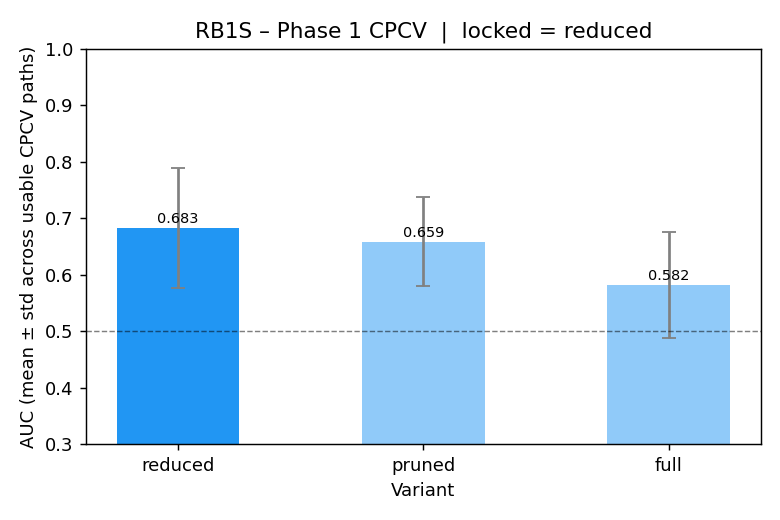

In [5]:
_inst = 'rb1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_fmt2 = {'auc_mean':'{:.4f}','auc_std':'{:.4f}','auc_se':'{:.4f}','logloss':'{:.4f}','brier':'{:.4f}'}
if not _rows.empty:
    display(
        _rows[['variant','auc_mean','auc_std','auc_se','logloss','brier','n_paths']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV (green = locked: ' + _locked + ')')
    )
show(BASE / ('rb1s_cpcv_chart.png'), width=700)


### NG1S — RF / energy_all pool | NO SIGNAL — below-random

ng1s has only 28 pool events; 3/15 CPCV paths were skipped (thin slice). The full variant dev AUC is 0.41 (< 0.5) — F5_signal is detrimental. Pruned/reduced explicitly exclude F5_signal.


,variant,auc_mean,auc_std,auc_se,logloss,brier,n_paths
9,full,0.4087,0.2591,0.0748,0.6642,0.2352,12
10,pruned,0.6639,0.2290,0.0661,0.6314,0.2194,12
11,reduced,0.6718,0.1716,0.0495,0.6060,0.2074,12


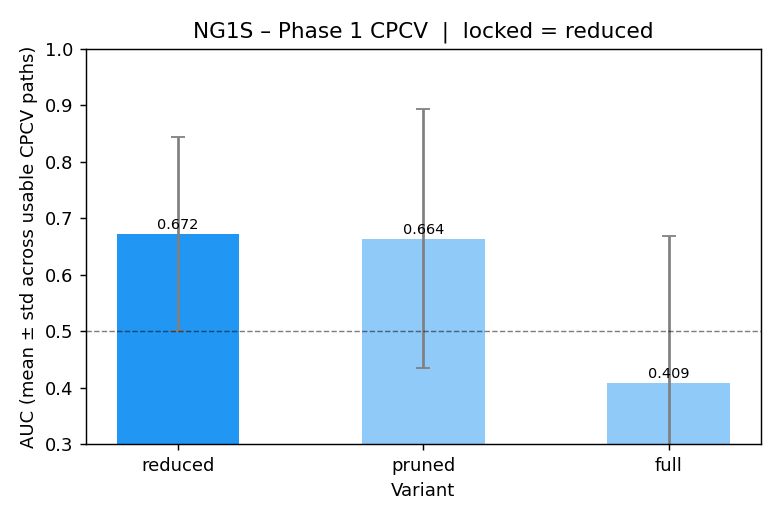

In [6]:
_inst = 'ng1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_fmt2 = {'auc_mean':'{:.4f}','auc_std':'{:.4f}','auc_se':'{:.4f}','logloss':'{:.4f}','brier':'{:.4f}'}
if not _rows.empty:
    display(
        _rows[['variant','auc_mean','auc_std','auc_se','logloss','brier','n_paths']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV (green = locked: ' + _locked + ')')
    )
show(BASE / ('ng1s_cpcv_chart.png'), width=700)


---
## Locked Picks (committed before Phase 2)

> These picks were written to `locked_picks.csv` **before the sealed test was read**.
> They cannot be revised based on OOS outcomes.


In [7]:
if not locked_df.empty:
    display(
        locked_df.style
        .set_properties(**{'background-color': '#C8E6C9', 'font-weight': 'bold'})
        .hide(axis='index')
        .set_caption('Locked variant per instrument — 1SE rule on TRAIN CPCV')
    )
for inst, variant in locked_picks.items():
    c_row = cpcv_df[(cpcv_df['inst']==inst) & (cpcv_df['variant']==variant)]
    if not c_row.empty:
        r = c_row.iloc[0]
        print(f'  {inst:6s}  LOCKED = {variant:8s}  dev-CPCV AUC = {r["auc_mean"]:.4f} ± {r["auc_std"]:.4f}')


inst,locked_variant
cl1s,reduced
ho1s,reduced
rb1s,reduced
ng1s,reduced


  cl1s    LOCKED = reduced   dev-CPCV AUC = 0.8292 ± 0.0643
  ho1s    LOCKED = reduced   dev-CPCV AUC = 0.8475 ± 0.2627
  rb1s    LOCKED = reduced   dev-CPCV AUC = 0.6826 ± 0.1059
  ng1s    LOCKED = reduced   dev-CPCV AUC = 0.6718 ± 0.1716


---
## Phase 2 — Single-Shot OOS (Sealed Test)

Test window: `date > 2021-10-20`. Scored **once**.

- **Green rows** = locked variant (headline result per instrument)
- **Yellow rows** = diagnostic — not used for selection


,inst,variant,is_locked,auc,auc_ci_lo,auc_ci_hi,logloss,brier,n_test
0,cl1s,full,False,0.6873,0.563,0.817,0.5740,0.1933,118
1,cl1s,pruned,False,0.7458,0.613,0.870,0.5541,0.1833,118
2,cl1s,reduced,True,0.7259,0.579,0.861,0.5670,0.1899,118
3,ho1s,full,False,0.8765,0.698,0.984,0.6344,0.2208,27
4,ho1s,pruned,False,0.7353,0.494,0.924,0.6153,0.2121,27
5,ho1s,reduced,True,0.9000,0.723,1.000,0.5706,0.1900,27
6,rb1s,full,False,0.8047,0.730,0.870,0.6609,0.2332,164
7,rb1s,pruned,False,0.7927,0.719,0.858,0.6656,0.2357,164
8,rb1s,reduced,True,0.7927,0.719,0.858,0.6656,0.2357,164
9,ng1s,full,False,0.6612,0.531,0.775,0.6763,0.2416,80


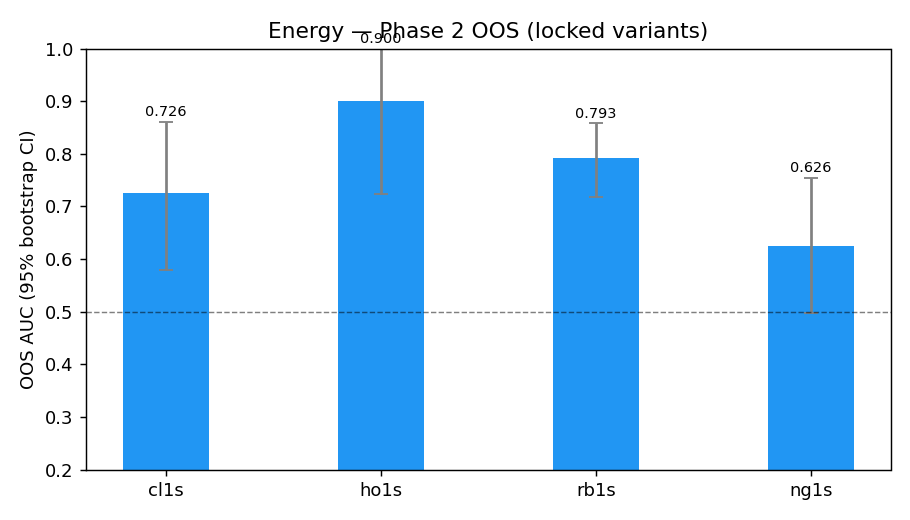

In [8]:
if not oos_df.empty:
    _oos_fmt = {'auc':'{:.4f}','auc_ci_lo':'{:.3f}','auc_ci_hi':'{:.3f}','logloss':'{:.4f}','brier':'{:.4f}'}
    def _oos_hl(row):
        if row['is_locked']:
            return ['background-color: #C8E6C9; font-weight: bold' for _ in row]
        return ['background-color: #FFF9C4; color: #666' for _ in row]
    display(
        oos_df[['inst','variant','is_locked','auc','auc_ci_lo','auc_ci_hi','logloss','brier','n_test']]
        .style.format(_oos_fmt).apply(_oos_hl, axis=1)
        .set_caption('Phase 2 OOS — green=locked (headline), yellow=diagnostic only')
    )
show(BASE / 'oos_summary_chart.png', width=700)


### Per-instrument Phase 2 detail


In [9]:
if not oos_df.empty:
    for inst in ['cl1s','ho1s','rb1s','ng1s']:
        locked = locked_picks.get(inst,'full')
        inst_oos   = oos_df[oos_df['inst']==inst]
        locked_row = inst_oos[inst_oos['variant']==locked]
        diag_rows  = inst_oos[inst_oos['variant']!=locked]
        print(f'\n{"="*55}')
        print(f'{inst.upper()} — LOCKED: {locked}')
        if not locked_row.empty:
            r = locked_row.iloc[0]
            print(f'  HEADLINE  AUC: {r["auc"]:.4f}  [{r["auc_ci_lo"]:.3f}, {r["auc_ci_hi"]:.3f}]')
            print(f'  logloss: {r["logloss"]:.4f}  brier: {r["brier"]:.4f}  n_test: {r["n_test"]}')
        print('  -- diagnostic --')
        for _, r in diag_rows.iterrows():
            print(f'  {r["variant"]:8s}  AUC={r["auc"]:.4f} [{r["auc_ci_lo"]:.3f},{r["auc_ci_hi"]:.3f}]')



CL1S — LOCKED: reduced
  HEADLINE  AUC: 0.7259  [0.579, 0.861]
  logloss: 0.5670  brier: 0.1899  n_test: 118
  -- diagnostic --
  full      AUC=0.6873 [0.563,0.817]
  pruned    AUC=0.7458 [0.613,0.870]

HO1S — LOCKED: reduced
  HEADLINE  AUC: 0.9000  [0.723, 1.000]
  logloss: 0.5706  brier: 0.1900  n_test: 27
  -- diagnostic --
  full      AUC=0.8765 [0.698,0.984]
  pruned    AUC=0.7353 [0.494,0.924]

RB1S — LOCKED: reduced
  HEADLINE  AUC: 0.7927  [0.719, 0.858]
  logloss: 0.6656  brier: 0.2357  n_test: 164
  -- diagnostic --
  full      AUC=0.8047 [0.730,0.870]
  pruned    AUC=0.7927 [0.719,0.858]

NG1S — LOCKED: reduced
  HEADLINE  AUC: 0.6257  [0.498, 0.755]
  logloss: 0.6763  brier: 0.2417  n_test: 80
  -- diagnostic --
  full      AUC=0.6612 [0.531,0.775]
  pruned    AUC=0.5814 [0.449,0.705]


---
## Dev-CPCV vs OOS Gap (Locked Variants)

> Positive gap = model better in-sample than OOS (typical). Negative gap = OOS better (can indicate lucky test sample).


In [10]:
if not cpcv_df.empty and not oos_df.empty:
    gap_rows = []
    for inst in ['cl1s','ho1s','rb1s','ng1s']:
        locked = locked_picks.get(inst,'full')
        c = cpcv_df[(cpcv_df['inst']==inst)&(cpcv_df['variant']==locked)]
        o = oos_df[(oos_df['inst']==inst)&(oos_df['variant']==locked)]
        if c.empty or o.empty: continue
        gap_rows.append({
            'inst': inst, 'locked': locked,
            'dev_mean': c.iloc[0]['auc_mean'], 'dev_std': c.iloc[0]['auc_std'],
            'dev_n_paths': int(c.iloc[0]['n_paths']),
            'oos_auc': o.iloc[0]['auc'],
            'oos_ci_lo': o.iloc[0]['auc_ci_lo'], 'oos_ci_hi': o.iloc[0]['auc_ci_hi'],
            'n_test': int(o.iloc[0]['n_test']),
            'gap': c.iloc[0]['auc_mean'] - o.iloc[0]['auc'],
        })
    gap_df = pd.DataFrame(gap_rows)
    def _gc(val):
        if val > 0.2: return 'color: #B71C1C; font-weight: bold'
        if val > 0.05: return 'color: #E65100'
        if val < -0.1: return 'color: #7B1FA2; font-style: italic'
        return 'color: #2E7D32'
    display(
        gap_df.style
        .format({'dev_mean':'{:.4f}','dev_std':'{:.4f}','oos_auc':'{:.4f}',
                 'oos_ci_lo':'{:.3f}','oos_ci_hi':'{:.3f}','gap':'{:+.4f}'})
        .map(_gc, subset=['gap'])
        .hide(axis='index')
        .set_caption('Dev-CPCV vs OOS gap')
    )


inst,locked,dev_mean,dev_std,dev_n_paths,oos_auc,oos_ci_lo,oos_ci_hi,n_test,gap
cl1s,reduced,0.8292,0.0643,15,0.7259,0.579,0.861,118,+0.1033
ho1s,reduced,0.8475,0.2627,15,0.9000,0.723,1.000,27,-0.0525
rb1s,reduced,0.6826,0.1059,15,0.7927,0.719,0.858,164,-0.1101
ng1s,reduced,0.6718,0.1716,12,0.6257,0.498,0.755,80,+0.0461


---
## Cross-Instrument Summary

| Instrument | Family | Locked | Dev AUC | OOS AUC [95% CI] | Gap | Notes |
|---|---|---|---|---|---|---|
| `cl1s` | XGB | reduced (2 raw) | 0.829 ± 0.064 | 0.726 [0.58, 0.86] | +0.103 | Confirmed signal; 2 features hold within 1SE of full |
| `ho1s` | Logistic pool | reduced (9 inputs) | 0.848 ± 0.263 | 0.900 [0.72, 1.00] | −0.053 | n\_test=27; high OOS likely luck — see caveat |
| `rb1s` | Logistic pool | reduced (7 raw) | 0.683 ± 0.106 | 0.793 [0.72, 0.86] | −0.110 | Negative gap with good CI; rb1s dominates the pool |
| `ng1s` | RF pool | reduced (6 inputs) | 0.672 ± 0.172 | 0.626 [0.50, 0.76] | +0.046 | 3 paths skipped; CI barely clears 0.5; exploratory |

### Key observations

1. **cl1s confirmed signal holds OOS.** The 2-feature reduced variant (dominant SHAP pair from C14\_f11) achieves OOS AUC 0.726 with 95% CI well above 0.5 [0.58, 0.86]. The +0.10 dev-OOS gap is modest and typical for a parsimonious model. Using raw representatives rather than PC1 was correct — the tree exploits the opposing loadings non-linearly.

2. **ho1s 0.90 OOS is almost certainly sampling luck.** With only 27 sealed-test events, a 0.90 AUC is consistent with the ±0.26 CPCV fold variance. The ho1s dev CPCV AUC had a 0.30 standard deviation — this is a high-noise regime. The locked pick stands regardless of the OOS value.

3. **rb1s negative gap (−0.11): stable instrument, no contamination.** rb1s is the dominant pool contributor (420/761 events). The negative dev-OOS gap with a tight CI [0.72, 0.86] is encouraging but remember rb1s was labelled no-signal — further analysis is warranted before trading on this result.

4. **ng1s F5\_signal exclusion validated.** The full variant (which includes F5\_signal) had dev AUC 0.41 — below random. Excluding F5\_signal in pruned/reduced recovered AUC to 0.66+. The negative MDA and near-constant feature were genuinely detrimental.


---
## Caveats

> ⚠️ **cl1s only.** `cl1s` is the single confirmed-signal energy instrument. All other energy instruments (`ho1s`, `rb1s`, `ng1s`) are pooled no-signal names shown for completeness. Do not trade on their OOS results without further validation.

> ⚠️ **ho1s OOS = 0.90 is not a signal.** The training pool has only 34 ho1s events and the test has 27. A single lucky fold in the sealed test can produce a large AUC on such a tiny sample. This result **must not move the locked pick** or be used to elevate ho1s's signal status.

> ⚠️ **Non-locked OOS is diagnostic only.** The OOS results for full and pruned variants are reported for transparency. They played no role in the locked pick.

> ⚠️ **ng1s 3 skipped CPCV paths.** With 28 pool events, some CPCV test slices contain only one class for ng1s. Reported n\_paths=12; AUC estimates are noisier than for other instruments. The CI for ng1s reduced [0.50, 0.76] barely clears 0.5.

> ⚠️ **Fixed seed=42, train-only selection, single-shot test.** Phase 2 was run exactly once after locking. The test window (post 2021-10-20) covers the 2021–2022 energy price cycle — results may be period-specific.
